# 25 - Code Challenge: Class Imbalance and the Accuracy Trap

**Section:** More on Data | **Prereqs:** `More on Data/Handeling_Unbalanced_Data_noise_augmentation.ipynb` | **Next:** `Regularization/Regularization_theory.ipynb`

Wine quality, binarised at two different thresholds. Threshold 4.5 splits the
data roughly evenly; threshold 6.5 leaves about 20% in the positive class.

**The trap.** With a 80/20 split, a model that predicts 'majority' for every
single sample scores 80% accuracy. That number looks respectable and the model is
worthless. Overall accuracy is not a usable metric on imbalanced data - which is
why this notebook tracks **per-class** accuracy, and why the whole
`Model Evaluation/` section exists.

**What you see:** at threshold 6.5, overall accuracy stays high while accuracy on
the minority class collapses. The model learned the base rate, not the pattern.

**The fixes**, none of which are in this notebook but all of which are worth
knowing: `pos_weight` in `BCEWithLogitsLoss`, a `WeightedRandomSampler`,
resampling, and reporting precision/recall/F1 instead of accuracy.

**Also new here:** `BCEWithLogitsLoss`, which fuses sigmoid and BCE into one
numerically stable op. With it, the model outputs raw logits and the decision
threshold becomes `logit > 0` rather than `probability > 0.5` - the same
boundary, since sigmoid(0) = 0.5.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

%matplotlib inline

# https://archive.ics.uci.edu/

In [ ]:
# UCI ML repository client - the dataset is fetched by numeric id.
!pip install ucimlrepo

In [ ]:
# Wine quality: 11 physicochemical features, quality scored 0-10.
from ucimlrepo import fetch_ucirepo

# fetch dataset
wine_quality = fetch_ucirepo(id=186)

# data (as pandas dataframes)
X = wine_quality.data.features
y = wine_quality.data.targets

cols = X.columns

In [ ]:
# 11 features.
X.columns.size

11

In [1]:
# Binarise: quality > 6.5 becomes class 1 ('good').
# Change this threshold to 4.5 and rerun the notebook - that is the experiment.
# 6.5 leaves roughly 20% positives; 4.5 is close to balanced.
y['Bool'] = (y['quality'] > 6.5).astype(int)

NameError: name 'y' is not defined

In [ ]:
y = y.drop('quality',axis =1)

In [ ]:
# The class counts. Check this on EVERY classification dataset before training;
# it decides which metrics are meaningful.
y['Bool'].value_counts()

,count
Bool,
0,5220
1,1277


In [ ]:
# StandardScaler: zero mean, unit variance per feature. The features here are on
# wildly different scales (pH ~3, sulphur dioxide ~100), and without scaling the
# large-magnitude ones dominate the gradient.
# The scaler is CREATED here but fitted after the split, in the next cell.
scaler = StandardScaler()
X = X.to_numpy()

In [ ]:
# Split FIRST, then fit the scaler on the training half only and apply it to
# both - so no test-set statistic ever reaches the model.
# Labels are float here, not long: BCEWithLogitsLoss expects float targets of
# the same shape as the output, unlike CrossEntropyLoss which wants int indices.
X_train, X_test, Y_train, Y_test = train_test_split(X, y.to_numpy(), test_size=0.20)

X_train = torch.tensor(scaler.fit_transform(X_train),dtype=torch.float,device='cuda')
X_test  = torch.tensor(scaler.transform(X_test),     dtype=torch.float,device='cuda')
Y_train = torch.tensor(Y_train,dtype=torch.float,device='cuda')
Y_test  = torch.tensor(Y_test, dtype=torch.float,device='cuda')

train_data = TensorDataset(X_train, Y_train)
test_data = TensorDataset(X_test,Y_test)

bs =32

train_loader4 = DataLoader(train_data, batch_size=bs, shuffle=True, drop_last=True)
test_loader4 = DataLoader(test_data, batch_size=test_data.tensors[0].shape[0])

In [ ]:
# 11 -> 64 -> 32 -> 1. One output unit and no sigmoid: the loss applies it.
class model(nn.Module):
  def __init__(self):
    super().__init__()

    self.model = nn.Sequential(
        nn.Linear(11,64),
        nn.ReLU(),
        nn.Linear(64,32),
        nn.ReLU(),
        nn.Linear(32,1)
    )

  def forward(self,x):
    return self.model(x)

In [ ]:
# BCEWithLogitsLoss = sigmoid + binary cross-entropy fused. More numerically
# stable than doing the two separately (it uses the log-sum-exp trick), and the
# recommended choice for binary classification.
# Because the output is a logit, the decision rule is `yhat > 0`, which is
# exactly `sigmoid(yhat) > 0.5`.
#
# The important part of this function is the per-class bookkeeping: zero_acc and
# one_acc index the correctness mask by true label, giving accuracy within each
# class separately.
def train_model(train_loader, test_loader):

  classifier = model()
  classifier.to('cuda')

  lr = 0.01
  epochs = 250
  lossFunc = nn.BCEWithLogitsLoss()

  optimizer = torch.optim.Adam(classifier.parameters(),lr = lr)


  train_acc = []
  test_acc = []
  losses = []
  one_acc = []
  zero_acc = []

  for epoch in range(epochs):

    classifier.train()

    batch_acc = []
    batch_loss = []

    for x,y in train_loader:

      yhat = classifier(x)

      loss = lossFunc(yhat,y)
      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      batch_acc.append(100 * torch.mean(((yhat > 0) == y).float().cpu()))

    losses.append(np.mean(batch_loss))
    train_acc.append(np.mean(batch_acc))

    classifier.eval()
    with torch.no_grad():

      # Here we calculate both total acc and accurcy based on class
      X,Y = next(iter(test_loader))
      preds = classifier(X)
      predVals = ((preds > 0) == Y).float()
      test_acc.append(100 * torch.mean(((preds > 0) == Y).float().cpu()))
      zero_acc.append(100 * torch.mean(predVals[Y == 0]).cpu())
      one_acc.append(100 * torch.mean(predVals[Y == 1]).cpu())


    if epoch % 50 == 0 or epoch == epochs - 1:
      print(f'Epoch {epoch} - Loss {losses[epoch]} - Val Accuracy : {test_acc[epoch]}')



  return train_acc, test_acc, losses, one_acc, zero_acc


In [ ]:
train_acc, test_acc, losses, one_acc, zero_acc   = train_model(train_loader4,test_loader4)

Epoch 0 - Loss 0.4115512095115803 - Val Accuracy : 84.53845977783203
Epoch 50 - Loss 0.2234967961723422 - Val Accuracy : 86.46154022216797
Epoch 100 - Loss 0.14644174183500402 - Val Accuracy : 86.0
Epoch 150 - Loss 0.11959531442204743 - Val Accuracy : 86.07691955566406
Epoch 200 - Loss 0.08359124445942817 - Val Accuracy : 85.76923370361328
Epoch 249 - Loss 0.08154708350703901 - Val Accuracy : 85.30769348144531


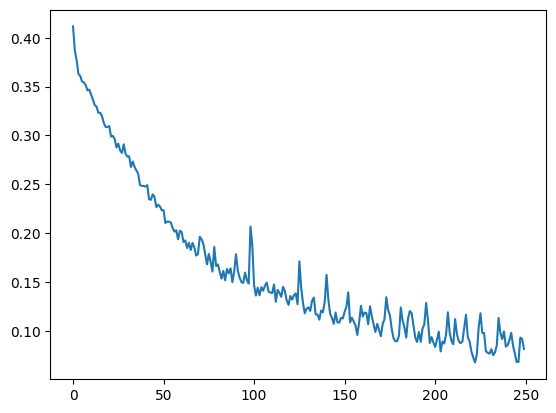

In [ ]:
# Loss curve - it falls nicely even when the model is failing on the minority
# class, because 80% of the samples are being fit well.
plt.plot(losses)

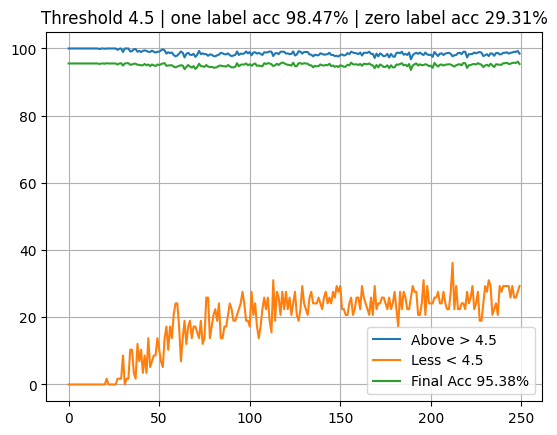

In [ ]:
# The per-class plot at threshold 4.5 (balanced): the two class lines track each
# other and overall accuracy is a fair summary.
plt.plot(one_acc, label="Above > 4.5")
plt.plot(zero_acc, label = "Less < 4.5")
plt.plot(test_acc, label=f"Final Acc {test_acc[-1]:.2f}%")
plt.grid()
plt.title(f'Threshold 4.5 | one label acc {one_acc[-1]:.2f}% | zero label acc {zero_acc[-1]:.2f}%')
plt.legend();

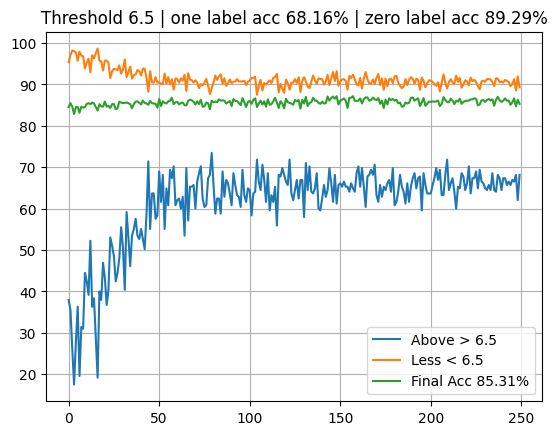

In [ ]:
# The same plot at threshold 6.5 (imbalanced). The minority-class line sits far
# below the majority line, while the overall accuracy stays high. That gap is
# the entire lesson of this notebook.
plt.plot(one_acc, label="Above > 6.5")
plt.plot(zero_acc, label = "Less < 6.5")
plt.plot(test_acc, label=f"Final Acc {test_acc[-1]:.2f}%")
plt.grid()
plt.title(f'Threshold 6.5 | one label acc {one_acc[-1]:.2f}% | zero label acc {zero_acc[-1]:.2f}%')
plt.legend();

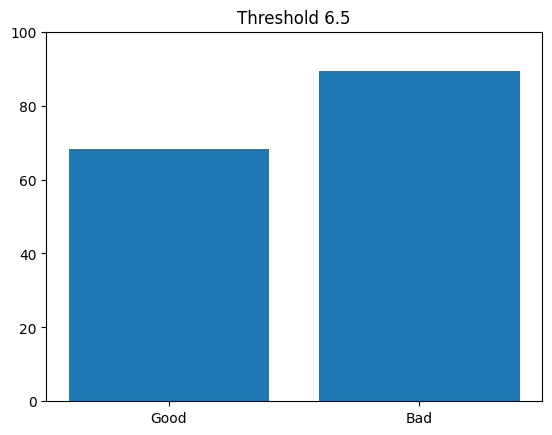

In [ ]:
# The final numbers as bars. A model that scores 90% on one class and 40% on
# the other is not a 85%-accurate model in any useful sense - it is a model that
# learned the base rate.
plt.bar(['Good','Bad'], [one_acc[-1],zero_acc[-1]]);
plt.title(f'Threshold 6.5')
plt.ylim([0,100]);


# Consclusion: If the data is baised, then the model learns bias too.